
# MAFS5370 Assignment 2: Super Tic-Tac-Toe RL Agent

**Optimised Jupyter Notebook Version**

This notebook implements and evaluates a reinforcement learning agent for the Super Tic-Tac-Toe assignment.

Main improvements over the initial draft:

1. Keeps the original staged design: small deterministic board → small noisy board → full triangular board.
2. Implements the full 96-cell triangular board with the assignment's noisy placement rule.
3. Uses tabular Q-learning for small boards and linear Q-learning with hand-crafted features for the full board.
4. Adds mixed-opponent training: the full-board agent trains against both random and heuristic opponents.
5. Adds tactical safeguards: immediate winning moves and immediate blocking moves are prioritised.
6. Evaluates the trained agent against random and heuristic opponents, both as first and second player.
7. Saves convergence curves and final evaluation tables for the written report.

> Recommended workflow: run all cells once with the default parameters. If runtime is too long, reduce `full_episodes` and `final_eval_games` in the experiment cell.

In [1]:
# ============================================================
# 0. Imports and global settings
# ============================================================

from __future__ import annotations

import csv
import math
import random
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Dict, List, Sequence, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 7
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

OUTPUT_DIR = Path("super_tictactoe_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

Player = int
State = Tuple[int, ...]   # 0 = empty, 1 = player 1, -1 = player 2
Action = int              # zero-based cell id

## 1. Board construction

The full board consists of six \(4 	imes 4\) squares arranged as a triangle:

- Level 1: 1 square
- Level 2: 2 squares
- Level 3: 3 squares

Thus the full board has \(6 	imes 16 = 96\) legal cells.  
Each cell is embedded into a two-dimensional coordinate system and also stores its `level`, which is needed for the special column-winning rule.

In [2]:
@dataclass(frozen=True)
class Cell:
    id: int
    x: int
    y: int
    level: int
    block: int


@dataclass
class Board:
    cells: List[Cell]

    def __post_init__(self) -> None:
        self.coord_to_id = {(c.x, c.y): c.id for c in self.cells}

    def __len__(self) -> int:
        return len(self.cells)

    def cell(self, action: Action) -> Cell:
        return self.cells[action]

    def id_at(self, x: int, y: int) -> Optional[int]:
        return self.coord_to_id.get((x, y))

    @property
    def xs(self) -> List[int]:
        return [c.x for c in self.cells]

    @property
    def ys(self) -> List[int]:
        return [c.y for c in self.cells]


def make_rect_board(n_rows: int = 4, n_cols: int = 4) -> Board:
    """Simple rectangular board used as a baseline environment."""
    cells: List[Cell] = []
    for y in range(1, n_rows + 1):
        for x in range(1, n_cols + 1):
            cells.append(Cell(len(cells), x, y, level=1, block=1))
    return Board(cells)


def make_super_board(block_size: int = 4) -> Board:
    """
    Six 4x4 squares arranged as a triangle:

            level 1:      [ block 1 ]
            level 2:   [ block 1 ][ block 2 ]
            level 3: [ block 1 ][ block 2 ][ block 3 ]

    The board is embedded into one coordinate grid so that rows, columns,
    and diagonals can be generated naturally.
    """
    blocks = [
        # level, block, block_x, block_y
        (1, 1, 3, 1),
        (2, 1, 2, 2),
        (2, 2, 3, 2),
        (3, 1, 1, 3),
        (3, 2, 2, 3),
        (3, 3, 3, 3),
    ]

    cells: List[Cell] = []
    for level, block, block_x, block_y in blocks:
        for r in range(1, block_size + 1):
            for col in range(1, block_size + 1):
                x = (block_x - 1) * block_size + col
                y = (block_y - 1) * block_size + r
                cells.append(Cell(len(cells), x, y, level, block))
    return Board(cells)


def new_state(board: Board) -> State:
    return tuple(0 for _ in range(len(board)))


def empty_actions(state: State) -> List[Action]:
    return [i for i, value in enumerate(state) if value == 0]

## 2. Game rules

Winning rules:

- 4 in a row;
- 4 in a column;
- 5 on a diagonal;
- for a column win, at least one of the four cells must be in a different level.

Noisy placement rule:

- probability \(1/2\): mark is placed at the chosen cell;
- probability \(1/16\) for each of the eight neighbouring cells;
- if the sampled cell is outside the board or already occupied, the move is forfeited.

In [3]:
@dataclass(frozen=True)
class Line:
    ids: Tuple[int, ...]
    kind: str


def generate_lines(board: Board, row_len: int = 4, diag_len: int = 5) -> List[Line]:
    """
    Generate every legal winning window:
    - row: length row_len
    - column: length row_len
    - diagonal: length diag_len
    """
    directions = {
        "row": (1, 0, row_len),
        "col": (0, 1, row_len),
        "diag_down": (1, 1, diag_len),
        "diag_up": (1, -1, diag_len),
    }

    seen = set()
    lines: List[Line] = []
    for cell in board.cells:
        for kind, (dx, dy, length) in directions.items():
            ids: List[int] = []
            for step in range(length):
                target = board.id_at(cell.x + dx * step, cell.y + dy * step)
                if target is None:
                    break
                ids.append(target)
            if len(ids) == length:
                key = (kind, tuple(ids))
                if key not in seen:
                    seen.add(key)
                    lines.append(Line(tuple(ids), kind))
    return lines


def line_valid_under_column_rule(board: Board, line: Line, column_must_cross_level: bool) -> bool:
    """Check whether a candidate winning line is valid under the special column rule."""
    if column_must_cross_level and line.kind == "col":
        levels = {board.cell(i).level for i in line.ids}
        return len(levels) >= 2
    return True


def place_mark(
    state: State,
    board: Board,
    action: Action,
    player: Player,
    noisy: bool = False,
) -> Tuple[State, bool, Optional[int]]:
    """
    Place a mark under deterministic or noisy placement.

    Returns:
    - new_state
    - placed: whether a mark was actually placed
    - target: actual target id, or None if outside the board
    """
    assert state[action] == 0

    target: Optional[int] = action
    if noisy and random.random() > 0.5:
        cell = board.cell(action)
        neighbours = [
            (dx, dy)
            for dx in (-1, 0, 1)
            for dy in (-1, 0, 1)
            if not (dx == 0 and dy == 0)
        ]
        dx, dy = random.choice(neighbours)
        target = board.id_at(cell.x + dx, cell.y + dy)

    if target is not None and state[target] == 0:
        state_list = list(state)
        state_list[target] = player
        return tuple(state_list), True, target

    return state, False, target


def check_win(
    state: State,
    board: Board,
    lines: Sequence[Line],
    player: Player,
    column_must_cross_level: bool = False,
) -> bool:
    """Check whether `player` has a valid winning line."""
    for line in lines:
        if not line_valid_under_column_rule(board, line, column_must_cross_level):
            continue
        if all(state[i] == player for i in line.ids):
            return True
    return False


def is_draw(state: State) -> bool:
    return all(value != 0 for value in state)

## 3. Policies and game simulation

We evaluate the learner against two opponents:

1. **Random opponent**: chooses uniformly among legal actions.
2. **Heuristic opponent**: takes immediate wins, blocks immediate threats, and otherwise chooses cells with stronger line potential and centrality.

The learner can be evaluated as either the first or the second player.

In [4]:
Policy = Callable[[State, Board, Player, Sequence[Line]], Action]


def random_policy(state: State, board: Board, player: Player, lines: Sequence[Line]) -> Action:
    return random.choice(empty_actions(state))


def immediate_winning_actions(
    state: State,
    board: Board,
    lines: Sequence[Line],
    player: Player,
    column_must_cross_level: bool = False,
) -> List[Action]:
    """Actions that would win immediately if the mark is placed exactly there."""
    winners = []
    for action in empty_actions(state):
        state_list = list(state)
        state_list[action] = player
        if check_win(tuple(state_list), board, lines, player, column_must_cross_level):
            winners.append(action)
    return winners


def action_line_potential(
    state: State,
    board: Board,
    lines: Sequence[Line],
    action: Action,
    player: Player,
    column_must_cross_level: bool = False,
) -> float:
    """
    Heuristic score for an action.
    Higher score means better own line potential and better blocking potential.
    """
    cell = board.cell(action)
    mean_x = sum(board.xs) / len(board.xs)
    mean_y = sum(board.ys) / len(board.ys)
    max_x = max(board.xs)
    max_y = max(board.ys)

    centrality = (1.0 - abs(cell.x - mean_x) / max_x) + (1.0 - abs(cell.y - mean_y) / max_y)

    own_score = 0.0
    block_score = 0.0
    for line in lines:
        if action not in line.ids:
            continue
        if not line_valid_under_column_rule(board, line, column_must_cross_level):
            continue
        values = [state[i] for i in line.ids]
        own = values.count(player)
        opp = values.count(-player)
        empty = values.count(0)

        if opp == 0:
            own_score += own ** 2 + 0.25 * empty
        if own == 0:
            block_score += opp ** 2

    return 0.60 * own_score + 0.35 * block_score + 0.05 * centrality


def heuristic_policy(
    state: State,
    board: Board,
    player: Player,
    lines: Sequence[Line],
    column_must_cross_level: bool = False,
) -> Action:
    """Simple tactical opponent: win, block, otherwise choose a high-potential action."""
    legal = empty_actions(state)

    wins = immediate_winning_actions(state, board, lines, player, column_must_cross_level)
    if wins:
        return random.choice(wins)

    blocks = immediate_winning_actions(state, board, lines, -player, column_must_cross_level)
    if blocks:
        return random.choice(blocks)

    scores = [
        action_line_potential(state, board, lines, a, player, column_must_cross_level)
        for a in legal
    ]
    best = max(scores)
    best_actions = [a for a, s in zip(legal, scores) if s == best]
    return random.choice(best_actions)


def mixed_opponent_policy(
    state: State,
    board: Board,
    player: Player,
    lines: Sequence[Line],
    heuristic_prob: float = 0.5,
    column_must_cross_level: bool = False,
) -> Action:
    """Opponent used in robust training: mixture of random and heuristic play."""
    if random.random() < heuristic_prob:
        return heuristic_policy(state, board, player, lines, column_must_cross_level)
    return random_policy(state, board, player, lines)


def play_episode(
    board: Board,
    lines: Sequence[Line],
    learner_policy: Policy,
    opponent_policy: Policy = random_policy,
    noisy: bool = False,
    column_must_cross_level: bool = False,
    learner_player: Player = 1,
) -> int:
    """
    Return from learner's perspective:
       1 = learner wins
       0 = draw
      -1 = learner loses
    """
    state = new_state(board)
    current_player = 1

    while empty_actions(state):
        policy = learner_policy if current_player == learner_player else opponent_policy
        action = policy(state, board, current_player, lines)
        if state[action] != 0:
            action = random_policy(state, board, current_player, lines)

        state, _, _ = place_mark(state, board, action, current_player, noisy=noisy)

        if check_win(state, board, lines, current_player, column_must_cross_level):
            return 1 if current_player == learner_player else -1
        if is_draw(state):
            return 0

        current_player *= -1

    return 0


def evaluate_policy(
    board: Board,
    lines: Sequence[Line],
    learner_policy: Policy,
    opponent_policy: Policy = random_policy,
    n_games: int = 200,
    noisy: bool = False,
    column_must_cross_level: bool = False,
    learner_player: Player = 1,
) -> Dict[str, float]:
    results = [
        play_episode(
            board,
            lines,
            learner_policy,
            opponent_policy,
            noisy=noisy,
            column_must_cross_level=column_must_cross_level,
            learner_player=learner_player,
        )
        for _ in range(n_games)
    ]
    return {
        "win_rate": results.count(1) / n_games,
        "draw_rate": results.count(0) / n_games,
        "loss_rate": results.count(-1) / n_games,
    }

## 4. Tabular Q-learning baseline for small boards

For the small rectangular boards, tabular Q-learning is feasible and provides a useful baseline.  
The learner moves, then the opponent moves, and the Q-update is applied from the learner's perspective.

In [5]:
def epsilon_greedy_tabular(Q: Dict[State, List[float]], state: State, epsilon: float, n_actions: int) -> Action:
    legal = empty_actions(state)
    if random.random() < epsilon:
        return random.choice(legal)

    q = Q.get(state, [0.0] * n_actions)
    best_value = max(q[a] for a in legal)
    best_actions = [a for a in legal if q[a] == best_value]
    return random.choice(best_actions)


def train_tabular_q(
    board: Board,
    lines: Sequence[Line],
    episodes: int = 1200,
    alpha: float = 0.20,
    gamma: float = 0.95,
    epsilon_start: float = 0.35,
    epsilon_end: float = 0.03,
    noisy: bool = False,
    column_must_cross_level: bool = False,
    eval_every: int = 100,
    eval_games: int = 80,
) -> Dict[str, object]:
    Q: Dict[State, List[float]] = {}
    n_actions = len(board)
    curve: List[Dict[str, float]] = []

    for episode in range(1, episodes + 1):
        epsilon = epsilon_end + (epsilon_start - epsilon_end) * math.exp(-episode / (episodes / 3))
        state = new_state(board)
        done = False

        while not done and empty_actions(state):
            action = epsilon_greedy_tabular(Q, state, epsilon, n_actions)
            old_state = state

            state, _, _ = place_mark(state, board, action, 1, noisy=noisy)
            if check_win(state, board, lines, 1, column_must_cross_level):
                reward = 1.0
                done = True
            elif is_draw(state):
                reward = 0.0
                done = True
            else:
                opp_action = random_policy(state, board, -1, lines)
                state, _, _ = place_mark(state, board, opp_action, -1, noisy=noisy)
                if check_win(state, board, lines, -1, column_must_cross_level):
                    reward = -1.0
                    done = True
                else:
                    reward = 0.0
                    done = is_draw(state)

            q = Q.setdefault(old_state, [0.0] * n_actions)
            target = reward
            if not done and empty_actions(state):
                next_q = Q.get(state, [0.0] * n_actions)
                target += gamma * max(next_q[a] for a in empty_actions(state))
            q[action] += alpha * (target - q[action])

        if episode % eval_every == 0:
            def greedy_policy(s: State, b: Board, p: Player, ls: Sequence[Line]) -> Action:
                return epsilon_greedy_tabular(Q, s, 0.0, len(b))

            score = evaluate_policy(
                board,
                lines,
                greedy_policy,
                random_policy,
                n_games=eval_games,
                noisy=noisy,
                column_must_cross_level=column_must_cross_level,
                learner_player=1,
            )
            curve.append({"episode": episode, **score})

    def policy(s: State, b: Board, p: Player, ls: Sequence[Line]) -> Action:
        return epsilon_greedy_tabular(Q, s, 0.0, len(b))

    return {"Q": Q, "policy": policy, "curve": curve}

## 5. Linear Q-learning for the full Super Tic-Tac-Toe board

For the full 96-cell board, tabular Q-learning is infeasible. We use a linear approximation:

\[
Q(s,a) pprox 	heta^	op \phi(s,a).
\]

The feature vector includes centrality, level indicators, own-line potential, opponent-line potential, immediate-win features, and immediate-block features.

Optimisations in this notebook:

1. The feature calculation respects the cross-level column rule.
2. The training opponent is a mixture of random and heuristic policies.
3. The greedy learner uses tactical safeguards for immediate wins and blocks.
4. Reward shaping encourages successful placement and blocking.

In [6]:
def make_line_cache(board: Board, lines: Sequence[Line]) -> List[List[int]]:
    by_action: List[List[int]] = [[] for _ in range(len(board))]
    for line_index, line in enumerate(lines):
        for action in line.ids:
            by_action[action].append(line_index)
    return by_action


def line_features_after_action(
    state: State,
    board: Board,
    lines: Sequence[Line],
    line_cache: List[List[int]],
    action: Action,
    player: Player,
    column_must_cross_level: bool = False,
) -> Tuple[int, int, bool, bool]:
    """Features based on lines containing the candidate action."""
    max_own_open = 0
    max_opp_open = 0
    win_now = False
    block_threat = False

    for line_index in line_cache[action]:
        line = lines[line_index]
        if not line_valid_under_column_rule(board, line, column_must_cross_level):
            continue

        values = [state[i] for i in line.ids]
        line_len = len(line.ids)
        own_before = values.count(player)
        opp_before = values.count(-player)

        if opp_before == 0:
            own_after = own_before + 1
            max_own_open = max(max_own_open, own_after)
            win_now = win_now or (own_after == line_len)

        if own_before == 0:
            max_opp_open = max(max_opp_open, opp_before)
            block_threat = block_threat or (opp_before >= line_len - 1)

    return max_own_open, max_opp_open, win_now, block_threat


FEATURE_NAMES = [
    "bias",
    "is_empty",
    "central_x",
    "central_y",
    "level_1",
    "level_2",
    "level_3",
    "own_open",
    "opp_open",
    "win_now",
    "block_threat",
    "occupied_ratio",
    "empty_ratio",
]


def features_for_action(
    state: State,
    board: Board,
    lines: Sequence[Line],
    line_cache: List[List[int]],
    action: Action,
    player: Player = 1,
    column_must_cross_level: bool = False,
) -> List[float]:
    cell = board.cell(action)
    mean_x = sum(board.xs) / len(board.xs)
    mean_y = sum(board.ys) / len(board.ys)
    max_x = max(board.xs)
    max_y = max(board.ys)

    own_open, opp_open, win_now, block_threat = line_features_after_action(
        state,
        board,
        lines,
        line_cache,
        action,
        player,
        column_must_cross_level,
    )

    return [
        1.0,
        1.0 if state[action] == 0 else 0.0,
        1.0 - abs(cell.x - mean_x) / max_x,
        1.0 - abs(cell.y - mean_y) / max_y,
        1.0 if cell.level == 1 else 0.0,
        1.0 if cell.level == 2 else 0.0,
        1.0 if cell.level == 3 else 0.0,
        own_open / 5.0,
        opp_open / 5.0,
        1.0 if win_now else 0.0,
        1.0 if block_threat else 0.0,
        sum(v != 0 for v in state) / len(board),
        sum(v == 0 for v in state) / len(board),
    ]


def dot(a: Sequence[float], b: Sequence[float]) -> float:
    return float(sum(x * y for x, y in zip(a, b)))


def q_values_linear(
    theta: Sequence[float],
    state: State,
    board: Board,
    lines: Sequence[Line],
    line_cache: List[List[int]],
    player: Player = 1,
    column_must_cross_level: bool = False,
) -> Dict[Action, float]:
    return {
        action: dot(
            theta,
            features_for_action(state, board, lines, line_cache, action, player, column_must_cross_level),
        )
        for action in empty_actions(state)
    }


def epsilon_greedy_linear(
    theta: Sequence[float],
    state: State,
    board: Board,
    lines: Sequence[Line],
    line_cache: List[List[int]],
    epsilon: float,
    player: Player = 1,
    column_must_cross_level: bool = False,
    tactical: bool = True,
) -> Action:
    legal = empty_actions(state)
    if not legal:
        raise ValueError("No legal actions available")

    if random.random() < epsilon:
        return random.choice(legal)

    if tactical:
        wins = immediate_winning_actions(state, board, lines, player, column_must_cross_level)
        if wins:
            return random.choice(wins)
        blocks = immediate_winning_actions(state, board, lines, -player, column_must_cross_level)
        if blocks:
            return random.choice(blocks)

    q = q_values_linear(theta, state, board, lines, line_cache, player, column_must_cross_level)
    best_value = max(q.values())
    best_actions = [a for a, value in q.items() if value == best_value]
    return random.choice(best_actions)


def train_linear_q(
    board: Board,
    lines: Sequence[Line],
    episodes: int = 1500,
    alpha: float = 0.035,
    gamma: float = 0.92,
    epsilon_start: float = 0.45,
    epsilon_end: float = 0.04,
    noisy: bool = True,
    column_must_cross_level: bool = True,
    eval_every: int = 100,
    eval_games: int = 100,
    heuristic_prob: float = 0.60,
    use_tactical_policy: bool = True,
    block_reward: float = 0.04,
    placement_reward: float = 0.01,
    forfeit_penalty: float = -0.02,
) -> Dict[str, object]:
    line_cache = make_line_cache(board, lines)
    n_features = len(features_for_action(new_state(board), board, lines, line_cache, 0, 1, column_must_cross_level))
    theta = [0.0] * n_features
    curve: List[Dict[str, float]] = []

    for episode in range(1, episodes + 1):
        epsilon = epsilon_end + (epsilon_start - epsilon_end) * math.exp(-episode / (episodes / 3))
        state = new_state(board)
        done = False

        while not done and empty_actions(state):
            action = epsilon_greedy_linear(
                theta,
                state,
                board,
                lines,
                line_cache,
                epsilon,
                player=1,
                column_must_cross_level=column_must_cross_level,
                tactical=use_tactical_policy,
            )
            phi = features_for_action(state, board, lines, line_cache, action, 1, column_must_cross_level)
            old_q = dot(theta, phi)

            # Was this intended action a defensive block?
            intended_blocks = action in immediate_winning_actions(
                state, board, lines, -1, column_must_cross_level
            )

            state, placed, _ = place_mark(state, board, action, 1, noisy=noisy)

            if check_win(state, board, lines, 1, column_must_cross_level):
                reward = 1.0
                done = True
            elif is_draw(state):
                reward = 0.0
                done = True
            else:
                # Mixed opponent training: sometimes random, sometimes heuristic.
                if random.random() < heuristic_prob:
                    opp_action = heuristic_policy(state, board, -1, lines, column_must_cross_level)
                else:
                    opp_action = random_policy(state, board, -1, lines)

                state, _, _ = place_mark(state, board, opp_action, -1, noisy=noisy)

                if check_win(state, board, lines, -1, column_must_cross_level):
                    reward = -1.0
                    done = True
                else:
                    reward = placement_reward if placed else forfeit_penalty
                    if intended_blocks:
                        reward += block_reward
                    done = is_draw(state)

            target = reward
            if not done and empty_actions(state):
                next_q = q_values_linear(theta, state, board, lines, line_cache, 1, column_must_cross_level)
                target += gamma * max(next_q.values())

            error = target - old_q
            theta = [max(-10.0, min(10.0, t + alpha * error * f)) for t, f in zip(theta, phi)]

        if episode % eval_every == 0:
            def greedy_policy(s: State, b: Board, p: Player, ls: Sequence[Line]) -> Action:
                return epsilon_greedy_linear(
                    theta,
                    s,
                    b,
                    ls,
                    line_cache,
                    0.0,
                    player=p,
                    column_must_cross_level=column_must_cross_level,
                    tactical=use_tactical_policy,
                )

            score = evaluate_policy(
                board,
                lines,
                greedy_policy,
                random_policy,
                n_games=eval_games,
                noisy=noisy,
                column_must_cross_level=column_must_cross_level,
                learner_player=1,
            )
            curve.append({"episode": episode, **score})

    def policy(s: State, b: Board, p: Player, ls: Sequence[Line]) -> Action:
        return epsilon_greedy_linear(
            theta,
            s,
            b,
            ls,
            line_cache,
            0.0,
            player=p,
            column_must_cross_level=column_must_cross_level,
            tactical=use_tactical_policy,
        )

    return {"theta": theta, "policy": policy, "curve": curve, "line_cache": line_cache}

## 6. Experiment runner

The experiment runner trains three agents:

1. `base_deterministic_tabular`: deterministic small board.
2. `base_noisy_tabular`: noisy small board.
3. `full_super_linear_mixed`: full 96-cell board with linear Q-learning and mixed-opponent training.

The final evaluation compares each agent against random and heuristic opponents, as both first and second player.

In [7]:
def summarize_convergence(results: Dict[str, Dict[str, object]], threshold: float = 0.60) -> pd.DataFrame:
    rows = []
    for name, result in results.items():
        curve = result["curve"]
        rows.append({
            "experiment": name,
            "final_win_rate": curve[-1]["win_rate"] if curve else np.nan,
            "best_win_rate": max(row["win_rate"] for row in curve) if curve else np.nan,
            "episodes_to_threshold": next((row["episode"] for row in curve if row["win_rate"] >= threshold), np.nan),
        })
    return pd.DataFrame(rows)


def run_random_vs_random_baseline(
    board: Board,
    lines: Sequence[Line],
    n_games: int,
    noisy: bool,
    column_must_cross_level: bool,
) -> Dict[str, float]:
    return evaluate_policy(
        board,
        lines,
        random_policy,
        random_policy,
        n_games=n_games,
        noisy=noisy,
        column_must_cross_level=column_must_cross_level,
        learner_player=1,
    )


def final_evaluate_experiment(
    name: str,
    board: Board,
    lines: Sequence[Line],
    policy: Policy,
    noisy: bool,
    column_must_cross_level: bool,
    n_games: int = 500,
) -> List[Dict[str, object]]:
    rows = []

    opponents = {
        "random": random_policy,
        "heuristic": lambda s, b, p, ls: heuristic_policy(s, b, p, ls, column_must_cross_level),
    }

    for opponent_name, opponent_policy in opponents.items():
        for learner_player, label in [(1, "first"), (-1, "second")]:
            score = evaluate_policy(
                board,
                lines,
                policy,
                opponent_policy,
                n_games=n_games,
                noisy=noisy,
                column_must_cross_level=column_must_cross_level,
                learner_player=learner_player,
            )
            rows.append({
                "experiment": name,
                "opponent": opponent_name,
                "learner_player": label,
                **score,
            })
    return rows


def run_all_experiments(
    run_small_tabular: bool = True,
    full_episodes: int = 1500,
    final_eval_games: int = 500,
    output_dir: str | Path = OUTPUT_DIR,
) -> Tuple[Dict[str, Dict[str, object]], pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    start = time.time()
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    results: Dict[str, Dict[str, object]] = {}
    boards: Dict[str, Board] = {}
    lines_dict: Dict[str, Sequence[Line]] = {}
    settings: Dict[str, Dict[str, object]] = {}

    if run_small_tabular:
        print("Step 1: base deterministic 4 x 4 board")
        base_board = make_rect_board(4, 4)
        base_lines = generate_lines(base_board, row_len=4, diag_len=4)
        base_det = train_tabular_q(
            base_board,
            base_lines,
            episodes=1200,
            noisy=False,
            eval_every=100,
            eval_games=80,
        )
        results["base_deterministic_tabular"] = base_det
        boards["base_deterministic_tabular"] = base_board
        lines_dict["base_deterministic_tabular"] = base_lines
        settings["base_deterministic_tabular"] = {"noisy": False, "column_must_cross_level": False}

        print("Step 2: same 4 x 4 board with noisy placement")
        base_noisy = train_tabular_q(
            base_board,
            base_lines,
            episodes=1600,
            noisy=True,
            eval_every=100,
            eval_games=80,
        )
        results["base_noisy_tabular"] = base_noisy
        boards["base_noisy_tabular"] = base_board
        lines_dict["base_noisy_tabular"] = base_lines
        settings["base_noisy_tabular"] = {"noisy": True, "column_must_cross_level": False}

    print("Step 3: full triangular super tic-tac-toe board with mixed-opponent linear Q-learning")
    super_board = make_super_board(4)
    super_lines = generate_lines(super_board, row_len=4, diag_len=5)
    full_linear = train_linear_q(
        super_board,
        super_lines,
        episodes=full_episodes,
        noisy=True,
        column_must_cross_level=True,
        eval_every=100,
        eval_games=100,
        heuristic_prob=0.60,
        use_tactical_policy=True,
        block_reward=0.04,
    )
    results["full_super_linear_mixed"] = full_linear
    boards["full_super_linear_mixed"] = super_board
    lines_dict["full_super_linear_mixed"] = super_lines
    settings["full_super_linear_mixed"] = {"noisy": True, "column_must_cross_level": True}

    # Convergence curves
    curve_rows = []
    for name, result in results.items():
        for row in result["curve"]:
            curve_rows.append({"experiment": name, **row})
    curve_df = pd.DataFrame(curve_rows)

    # Final evaluation
    eval_rows = []
    for name, result in results.items():
        eval_rows.extend(final_evaluate_experiment(
            name,
            boards[name],
            lines_dict[name],
            result["policy"],
            noisy=bool(settings[name]["noisy"]),
            column_must_cross_level=bool(settings[name]["column_must_cross_level"]),
            n_games=final_eval_games,
        ))

    # Random-vs-random baseline on full board
    rr_score = run_random_vs_random_baseline(
        super_board,
        super_lines,
        n_games=final_eval_games,
        noisy=True,
        column_must_cross_level=True,
    )
    eval_rows.append({
        "experiment": "full_super_random_vs_random",
        "opponent": "random",
        "learner_player": "first",
        **rr_score,
    })

    eval_df = pd.DataFrame(eval_rows)
    summary_df = summarize_convergence(results, threshold=0.60)

    # Save outputs
    curve_df.to_csv(output_dir / "convergence_curves.csv", index=False)
    eval_df.to_csv(output_dir / "final_evaluation_table.csv", index=False)
    summary_df.to_csv(output_dir / "convergence_summary.csv", index=False)

    elapsed = time.time() - start
    print(f"Finished all experiments in {elapsed:.2f} seconds")
    print(f"Saved outputs to: {output_dir.resolve()}")

    return results, curve_df, eval_df, summary_df

## 7. Run experiments

If this cell takes too long, reduce `full_episodes` or `final_eval_games`.  
For a quick test, use `full_episodes=500` and `final_eval_games=200`.  
For a stronger final result, use `full_episodes=1500` or `2000`, and `final_eval_games=500`.

In [8]:
results, curve_df, eval_df, summary_df = run_all_experiments(
    run_small_tabular=True,
    full_episodes=1500,
    final_eval_games=500,
    output_dir=OUTPUT_DIR,
)

Step 1: base deterministic 4 x 4 board
Step 2: same 4 x 4 board with noisy placement
Step 3: full triangular super tic-tac-toe board with mixed-opponent linear Q-learning
Finished all experiments in 5584.05 seconds
Saved outputs to: C:\Users\jay rong\Downloads\super_tictactoe_outputs


## 8. Convergence results

In [9]:
curve_df.head(), curve_df.tail()

(                   experiment  episode  win_rate  draw_rate  loss_rate
 0  base_deterministic_tabular      100    0.3625     0.5000     0.1375
 1  base_deterministic_tabular      200    0.3000     0.3625     0.3375
 2  base_deterministic_tabular      300    0.4500     0.3500     0.2000
 3  base_deterministic_tabular      400    0.3125     0.3875     0.3000
 4  base_deterministic_tabular      500    0.2375     0.4750     0.2875,
                  experiment  episode  win_rate  draw_rate  loss_rate
 38  full_super_linear_mixed     1100       1.0        0.0        0.0
 39  full_super_linear_mixed     1200       1.0        0.0        0.0
 40  full_super_linear_mixed     1300       1.0        0.0        0.0
 41  full_super_linear_mixed     1400       1.0        0.0        0.0
 42  full_super_linear_mixed     1500       1.0        0.0        0.0)

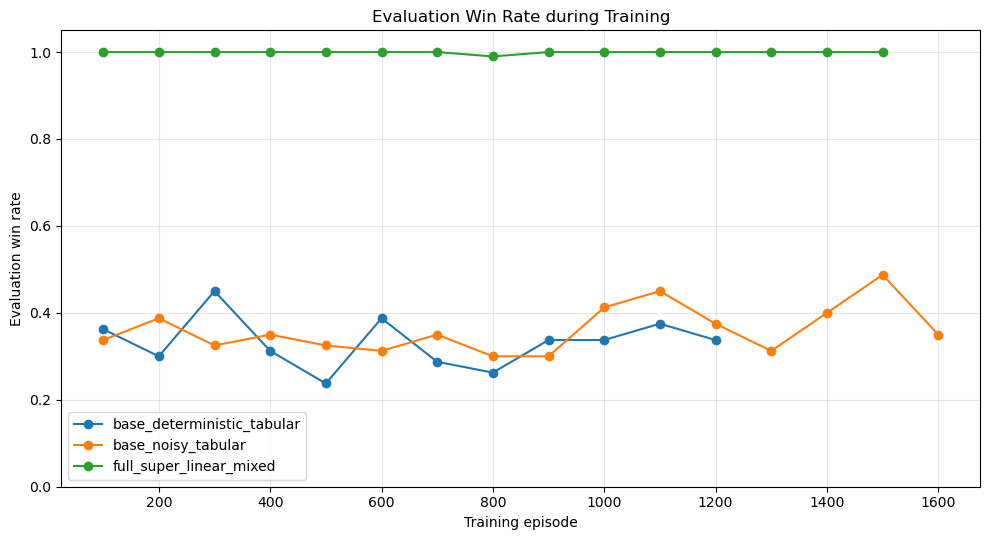

In [10]:
plt.figure(figsize=(10, 5.5))
for name, group in curve_df.groupby("experiment"):
    plt.plot(group["episode"], group["win_rate"], marker="o", label=name)
plt.xlabel("Training episode")
plt.ylabel("Evaluation win rate")
plt.title("Evaluation Win Rate during Training")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "convergence_curves.png", dpi=200)
plt.show()

In [11]:
summary_df

,experiment,final_win_rate,best_win_rate,episodes_to_threshold
0,base_deterministic_tabular,0.3375,0.4500,NaN
1,base_noisy_tabular,0.3500,0.4875,NaN
2,full_super_linear_mixed,1.0000,1.0000,100.0


## 9. Final evaluation table

This table compares each trained learner against random and heuristic opponents, both as the first and second player.

In [12]:
eval_df

,experiment,opponent,learner_player,win_rate,draw_rate,loss_rate
0,base_deterministic_tabular,random,first,0.322,0.398,0.280
1,base_deterministic_tabular,random,second,0.298,0.420,0.282
2,base_deterministic_tabular,heuristic,first,0.000,0.044,0.956
3,base_deterministic_tabular,heuristic,second,0.000,0.022,0.978
4,base_noisy_tabular,random,first,0.348,0.328,0.324
5,base_noisy_tabular,random,second,0.294,0.348,0.358
6,base_noisy_tabular,heuristic,first,0.066,0.136,0.798
7,base_noisy_tabular,heuristic,second,0.030,0.074,0.896
8,full_super_linear_mixed,random,first,1.000,0.000,0.000
9,full_super_linear_mixed,random,second,1.000,0.000,0.000


In [13]:
# Cleaner full-board-only table for report
full_eval_df = eval_df[eval_df["experiment"].str.contains("full_super")].reset_index(drop=True)
full_eval_df

,experiment,opponent,learner_player,win_rate,draw_rate,loss_rate
0,full_super_linear_mixed,random,first,1.000,0.0,0.000
1,full_super_linear_mixed,random,second,1.000,0.0,0.000
2,full_super_linear_mixed,heuristic,first,0.458,0.0,0.542
3,full_super_linear_mixed,heuristic,second,0.366,0.0,0.634
4,full_super_random_vs_random,random,first,0.490,0.0,0.510


## 10. Learned feature weights

The feature weights help interpret the learned policy.  
In particular, we expect positive weights on `own_open`, `win_now`, and ideally `block_threat`.

In [14]:
full_theta = results["full_super_linear_mixed"]["theta"]
theta_df = pd.DataFrame({"feature": FEATURE_NAMES, "theta": full_theta})
theta_df

,feature,theta
0,bias,0.079574
1,is_empty,0.079574
2,central_x,0.001953
3,central_y,0.011248
4,level_1,0.034077
5,level_2,0.027915
6,level_3,0.017583
7,own_open,0.272091
8,opp_open,-0.017509
9,win_now,0.186627


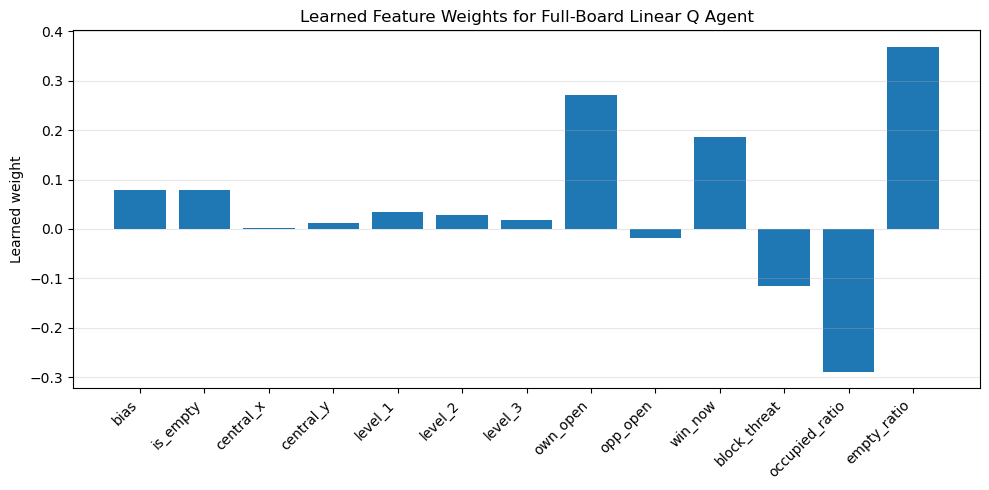

In [15]:
plt.figure(figsize=(10, 5))
plt.bar(theta_df["feature"], theta_df["theta"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Learned weight")
plt.title("Learned Feature Weights for Full-Board Linear Q Agent")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_weights.png", dpi=200)
plt.show()

## 11. Board visualisation

This plot visualises the embedded full board and the three levels.

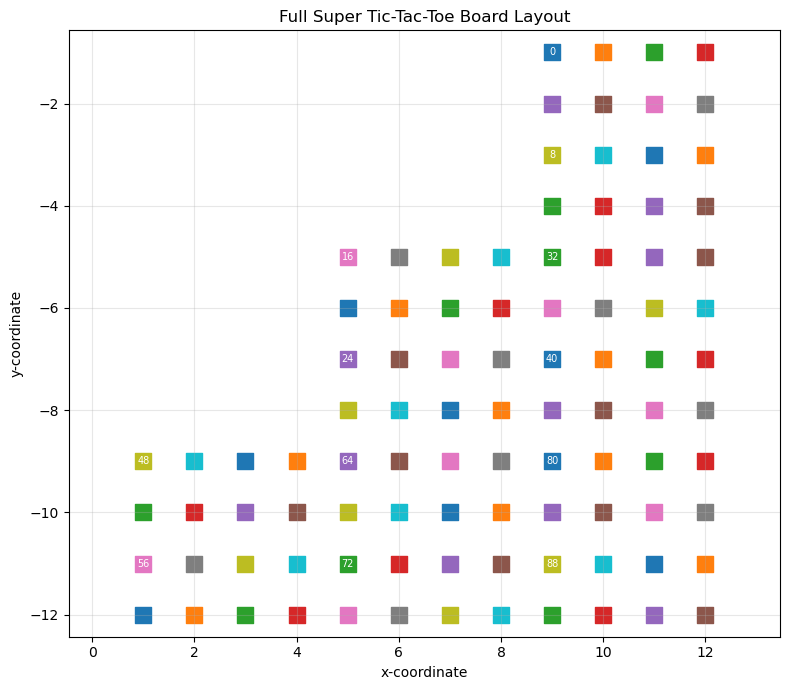

In [16]:
def plot_board_layout(board: Board, title: str = "Full Super Tic-Tac-Toe Board Layout") -> None:
    plt.figure(figsize=(8, 7))
    for cell in board.cells:
        plt.scatter(cell.x, -cell.y, s=130, marker="s")
        # Label every 8th cell only to avoid clutter
        if cell.id % 8 == 0:
            plt.text(cell.x, -cell.y, str(cell.id), ha="center", va="center", fontsize=7, color="white")
    plt.title(title)
    plt.xlabel("x-coordinate")
    plt.ylabel("y-coordinate")
    plt.grid(True, alpha=0.3)
    plt.axis("equal")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "board_layout.png", dpi=200)
    plt.show()

plot_board_layout(make_super_board(4))

## 12. Short interpretation template for report

You may use the following points in the PDF report:

- The full-board linear Q agent performs strongly against the random opponent.
- The random-vs-random baseline is close to 50%, so the high trained-agent win rate is not only due to first-player advantage.
- The heuristic opponent is more difficult, because it actively wins and blocks immediate threats.
- Mixed-opponent training and block reward are introduced to improve robustness relative to a purely random-opponent training setup.
- The method remains limited because the function approximation is linear and uses hand-crafted features rather than a deep network.